# 03 — AI 모델 학습 · 평가 (Training & Evaluation)

> 다양한 모델을 학습하고, LOGO 기반 일반화 성능을 중심으로 평가합니다.

## 구성

1) 데이터 로드 & 최소 전처리 (필요 시)  

2) 선형 모델 베이스라인  
   - Ridge / Lasso / ElasticNet / PLS  
   - KFold / LOGO 평가  

3) GAM (해석 중심 모델)  
   - KFold / LOGO  

4) 트리 기반 모델  
   - RandomForest / CatBoost / (옵션) XGBoost  
   - KFold / LOGO  

5) CatBoost 튜닝  
   - 하이퍼파라미터 조정  
   - LOGO 기반 최적화  

6) 성능 평가 및 시각화  
   - 시나리오별 R²  
   - 에러 분포  
   - Permutation Importance  

7) 최종 모델 선택 및 저장  


## 산출물

- model/final_catboost_multi.cbm  
  → 최종 모델  

- model/metadata.json  
  → 입력 변수, 타깃 정보  

- artifacts/*.csv / *.png  
  → 성능 결과 및 시각화  

## 핵심

- LOGO 기반 일반화 성능 평가  
- 모델 성능 + 해석 가능성 동시 고려  

=== Train(All) 성능 (평균) === {'MAE': 0.004, 'RMSE': 0.005, 'R2': 1.0}

=== LOGO 성능 (fold-by-scenario) ===
test_scenario      MAE     RMSE        R2
     SSP5-8.5 0.318656 0.423508 -0.017391
     SSP1-2.6 0.485209 0.575213  0.354814
     SSP3-7.0 0.317222 0.407819  0.346143
MEAN: {'MAE': 0.374, 'RMSE': 0.469, 'R2': 0.228}


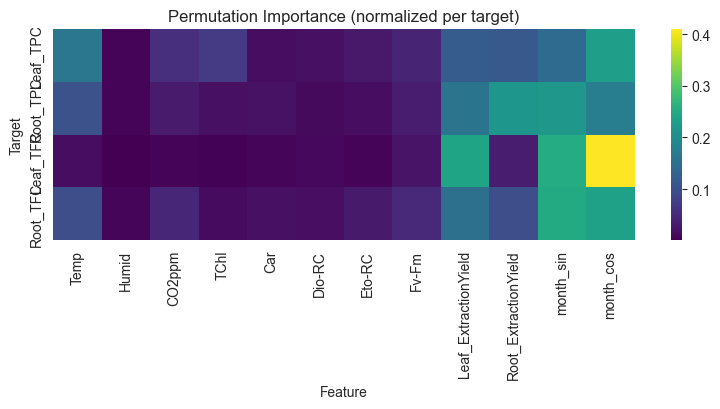

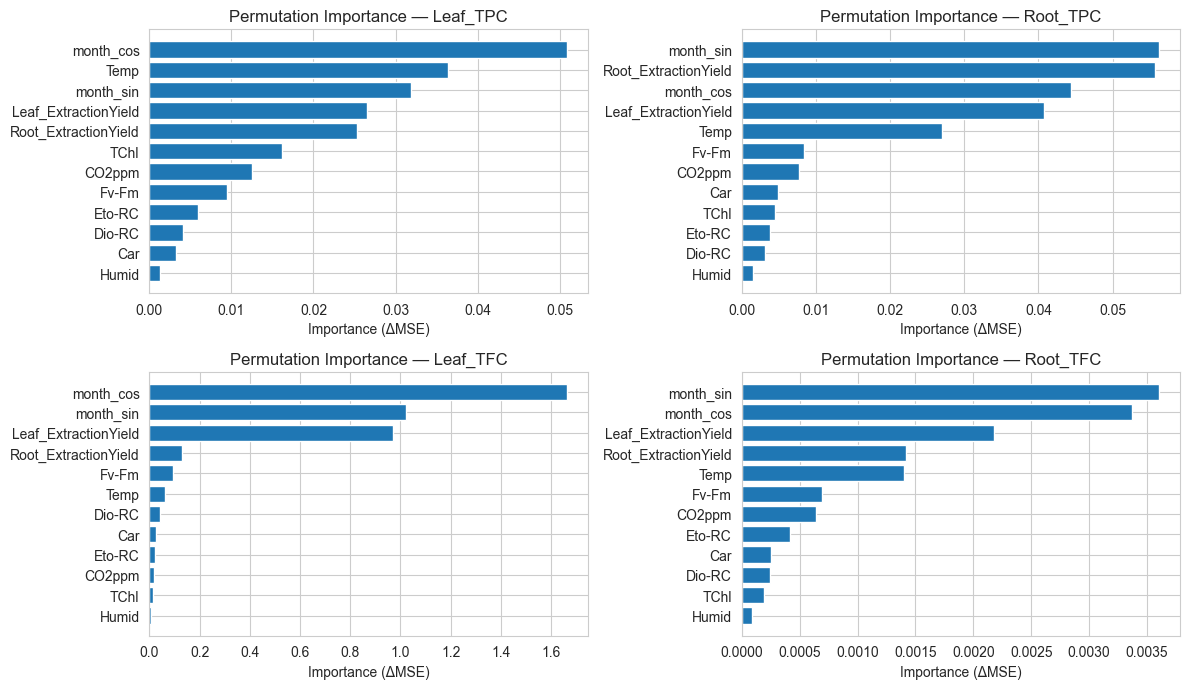

saved → model/quantile_q05_*.cbm, model/quantile_q95_*.cbm

[PI coverage on train (quick check)]


,target,coverage_90%
0,Leaf_TPC,0.810
1,Root_TPC,0.830
2,Leaf_TFC,0.874
3,Root_TFC,0.746



[Demo] 단일 입력 예측 (중앙값+90% PI)
    Leaf_TPC  Root_TPC  Leaf_TFC  Root_TFC  Leaf_TPC_lo90  Leaf_TPC_hi90  \
0  7.821425     5.341  6.587817  0.653638       7.551732       7.532479   

   Root_TPC_lo90  Root_TPC_hi90  Leaf_TFC_lo90  Leaf_TFC_hi90  Root_TFC_lo90  \
0       5.747584       5.562888        7.52587       6.638887       0.768243   

   Root_TFC_hi90  
0        0.71765  


CO2ppm,450,800,1150
Temp,,,
20,7.821,7.821,7.821
21,7.821,7.821,7.821
22,7.821,7.821,7.821
23,7.821,7.821,7.821
24,7.821,7.821,7.821
25,7.821,7.821,7.821
26,7.821,7.821,7.821
27,7.821,7.821,7.821


In [4]:
import os, json, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from catboost import CatBoostRegressor, Pool

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_style("whitegrid")
np.random.seed(42); random.seed(42)

# ------------------------------
# 0) 경로/디렉토리 & 공통 정의
# ------------------------------
os.makedirs("data/processed", exist_ok=True)
os.makedirs("model", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

META_P = "model/metadata.json"
DATA_P = "data/processed/processed.csv"
FINAL_MODEL_P = "model/final_catboost_multi.cbm"

final_features = [
    "Temp","Humid","CO2ppm",
    "TChl","Car","Dio-RC","Eto-RC","Fv-Fm",
    "Leaf_ExtractionYield","Root_ExtractionYield",
    "month_sin","month_cos"
]
targets = ["Leaf_TPC","Root_TPC","Leaf_TFC","Root_TFC"]

def scenario_label(co2):
    # 01_preprocessing.ipynb에서 사용한 경계(633 / 961)와 동일
    if co2 < 633:     return "SSP1-2.6"
    elif co2 < 961:   return "SSP3-7.0"
    else:             return "SSP5-8.5"

def ensure_month_feats(df, month_col="month"):
    if ("month_sin" not in df.columns) or ("month_cos" not in df.columns):
        if month_col in df.columns:
            m = df[month_col].astype(float)
            df["month_sin"] = np.sin(2*np.pi*m/12)
            df["month_cos"] = np.cos(2*np.pi*m/12)
        else:
            # month가 없다면 기본(중간월 근사)으로 채움
            df["month_sin"] = 0.5
            df["month_cos"] = 0.8660254037844386  # cos(60°)
    return df

def metrics_all(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mae  = [mean_absolute_error(y_true[:,i], y_pred[:,i]) for i in range(y_true.shape[1])]
    rmse = [np.sqrt(mean_squared_error(y_true[:,i], y_pred[:,i])) for i in range(y_true.shape[1])]
    r2   = [r2_score(y_true[:,i], y_pred[:,i]) for i in range(y_true.shape[1])]
    return float(np.mean(mae)), float(np.mean(rmse)), float(np.mean(r2)), mae, rmse, r2

def build_multi(params, seed=42):
    return CatBoostRegressor(
        loss_function="MultiRMSE",
        iterations=params.get("iterations", 3000),
        learning_rate=params["learning_rate"],
        depth=params["depth"],
        l2_leaf_reg=params["l2_leaf_reg"],
        bootstrap_type="Bernoulli",
        subsample=params["subsample"],
        colsample_bylevel=params["colsample_bylevel"],
        random_strength=params["random_strength"],
        random_seed=seed,
        verbose=False
    )

def build_quantile(alpha, base_params, seed=42):
    return CatBoostRegressor(
        loss_function=f"Quantile:alpha={alpha}",
        iterations=base_params["iterations"],
        learning_rate=base_params["learning_rate"],
        depth=base_params["depth"],
        l2_leaf_reg=base_params["l2_leaf_reg"],
        bootstrap_type="Bernoulli",
        subsample=base_params["subsample"],
        colsample_bylevel=base_params["colsample_bylevel"],
        random_seed=seed,
        verbose=False
    )

# ------------------------------
# 1) 데이터/메타/모델 로드 (없으면 최소 전처리 + 학습)
# ------------------------------
use_in_memory = all(n in globals() for n in ["X","y","groups"])
if not use_in_memory:
    if not os.path.exists(DATA_P):
        raise FileNotFoundError("data/processed/processed.csv 필요. (또는 01_preprocessing 실행)")
    df = pd.read_csv(DATA_P)
    df = ensure_month_feats(df)
    if "scenario_group" not in df.columns and "CO2ppm" in df.columns:
        df["scenario_group"] = df["CO2ppm"].apply(scenario_label)
    X = df[final_features].copy()
    y = df[targets].copy().values
    groups = df["scenario_group"].astype(str).values

# best 파라미터 로드(있으면), 없으면 fallback
if os.path.exists(META_P):
    with open(META_P, "r", encoding="utf-8") as f:
        meta_loaded = json.load(f)
    feature_cols_from_meta = meta_loaded.get("feature_cols", final_features)
    # feature 순서 보정
    if list(feature_cols_from_meta) != list(X.columns):
        X = X[feature_cols_from_meta].copy()
else:
    meta_loaded = None

if 'best_global' in globals():
    best = {k: best_global[k] for k in [
        "learning_rate","depth","l2_leaf_reg",
        "subsample","colsample_bylevel","random_strength","iterations"
    ]}
else:
    # fallback (이전 대화와 동일 기본값)
    best = dict(learning_rate=0.05, depth=5, l2_leaf_reg=10, subsample=0.6,
                colsample_bylevel=0.9, random_strength=2.0, iterations=3000)

# 최종 모델 로드 또는 학습
final_model = CatBoostRegressor()
if os.path.exists(FINAL_MODEL_P):
    final_model.load_model(FINAL_MODEL_P)
else:
    final_model = build_multi(best, seed=42)
    final_model.fit(X.values, y, verbose=False)
    final_model.save_model(FINAL_MODEL_P, format="cbm")

# 메타데이터 최신화 저장
meta = dict(
    best_params=best,
    target_names=targets,
    feature_cols=list(X.columns),
    seed=42, n_samples=int(X.shape[0]), n_features=int(X.shape[1])
)
with open(META_P, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

# ------------------------------
# 2) 성능지표 — Train 전체 & LOGO
# ------------------------------
# (A) Train 전체 스냅샷
y_hat_full = final_model.predict(X.values)
mae_mean, rmse_mean, r2_mean, mae_list, rmse_list, r2_list = metrics_all(y, y_hat_full)

overall_df = pd.DataFrame({
    "target": targets,
    "MAE": mae_list, "RMSE": rmse_list, "R2": r2_list
})
overall_mean = {"MAE": mae_mean, "RMSE": rmse_mean, "R2": r2_mean}

print("=== Train(All) 성능 (평균) ===", {k: round(v,3) for k,v in overall_mean.items()})

# (B) LOSO(시나리오별 Leave-One-Group-Out) — 각 fold는 재학습(정석)
rows, per_tgt_rows = [], []
gkf = GroupKFold(n_splits=len(np.unique(groups)))
for tr, te in gkf.split(X.values, y, groups):
    test_scen = np.unique(groups[te])[0]
    m = build_multi(best, seed=42)
    m.fit(X.values[tr], y[tr], eval_set=Pool(X.values[te], y[te]), early_stopping_rounds=200, verbose=False)
    pred = m.predict(X.values[te])
    mae_m, rmse_m, r2_m, m_mae, m_rmse, m_r2 = metrics_all(y[te], pred)
    rows.append({"test_scenario": test_scen, "MAE": mae_m, "RMSE": rmse_m, "R2": r2_m})
    for i, t in enumerate(targets):
        per_tgt_rows.append({"test_scenario": test_scen, "target": t,
                             "MAE": m_mae[i], "RMSE": m_rmse[i], "R2": m_r2[i]})

df_logo = pd.DataFrame(rows)
df_logo_tgt = pd.DataFrame(per_tgt_rows)
logo_mean = df_logo[["MAE","RMSE","R2"]].mean().to_dict()

print("\n=== LOGO 성능 (fold-by-scenario) ===")
print(df_logo.to_string(index=False))
print("MEAN:", {k: round(v,3) for k,v in logo_mean.items()})

# 저장
overall_df.to_csv("artifacts/metrics_train_all_per_target.csv", index=False, encoding="utf-8")
df_logo.to_csv("artifacts/metrics_logo_by_scenario.csv", index=False, encoding="utf-8")
df_logo_tgt.to_csv("artifacts/metrics_logo_by_scenario_per_target.csv", index=False, encoding="utf-8")

# ------------------------------
# 3) Permutation Importance (PI) — 모든 타깃
# ------------------------------
class CatWrapSingle(RegressorMixin, BaseEstimator):
    def __init__(self, model, k=0):
        self.model = model
        self.k = k
    def fit(self, X, y): 
        return self
    def predict(self, X):
        pred = self.model.predict(X)
        return pred[:, self.k] if pred.ndim == 2 else pred

def perm_importance_all_targets(model, X_df, y_arr, target_names, n_repeats=10, random_state=42, n_jobs=-1):
    assert isinstance(X_df, pd.DataFrame), "X_df는 DataFrame이어야 함."
    assert isinstance(y_arr, np.ndarray) and y_arr.ndim == 2, "y_arr는 (n_samples, n_targets) 2D여야 함."
    assert len(target_names) == y_arr.shape[1], "target_names 길이가 y_arr 컬럼수와 같아야 함."

    feat_names = X_df.columns.tolist()
    results = {}
    for k, tgt in enumerate(target_names):
        wrap = CatWrapSingle(model, k=k)
        r = permutation_importance(
            estimator=wrap,
            X=X_df.values,
            y=y_arr[:, k],
            n_repeats=n_repeats,
            random_state=random_state,
            scoring="neg_mean_squared_error",
            n_jobs=n_jobs
        )
        results[tgt] = pd.Series(r.importances_mean, index=feat_names).sort_values(ascending=False)
    return results

X_df = X if isinstance(X, pd.DataFrame) else pd.DataFrame(X, columns=final_features)
y_np = y if isinstance(y, np.ndarray) else y.values

pi_dict = perm_importance_all_targets(
    model=final_model,
    X_df=X_df,
    y_arr=y_np,
    target_names=targets,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
pi_df = pd.DataFrame(pi_dict).loc[X_df.columns]   # 피처 순서 고정
pi_norm = pi_df.div(pi_df.sum(axis=0).replace(0, np.nan), axis=1)

# 표/그림 저장
pi_df.to_csv("artifacts/permutation_importance_raw.csv", encoding="utf-8")
pi_norm.to_csv("artifacts/permutation_importance_norm.csv", encoding="utf-8")

plt.figure(figsize=(8, max(4, 0.35*len(X_df.columns))))
sns.heatmap(pi_norm.T, annot=False, cmap="viridis")
plt.title("Permutation Importance (normalized per target)")
plt.xlabel("Feature"); plt.ylabel("Target")
plt.tight_layout()
plt.savefig("artifacts/permutation_importance_heatmap.png", dpi=160)
plt.show()

n_cols = 2
n_rows = int(np.ceil(len(targets)/n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5*n_rows))
axes = np.ravel(axes)
for i, tgt in enumerate(targets):
    s = pi_df[tgt].sort_values(ascending=True)
    axes[i].barh(s.index, s.values)
    axes[i].set_title(f"Permutation Importance — {tgt}")
    axes[i].set_xlabel("Importance (ΔMSE)")
for j in range(i+1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("artifacts/permutation_importance_barplots.png", dpi=160)
plt.show()

# ------------------------------
# 4) Quantile(0.05/0.95) 학습/저장 + 커버리지
# ------------------------------
q_models = {}
for k, tgt in enumerate(targets):
    yk = y[:,k]
    q05 = build_quantile(0.05, best, seed=42)
    q95 = build_quantile(0.95, best, seed=42)
    q05.fit(X.values, yk); q95.fit(X.values, yk)
    q_models[tgt] = {"q05": q05, "q95": q95}
    q05.save_model(f"model/quantile_q05_{tgt}.cbm")
    q95.save_model(f"model/quantile_q95_{tgt}.cbm")
print("saved → model/quantile_q05_*.cbm, model/quantile_q95_*.cbm")

cov_rows=[]
for k, tgt in enumerate(targets):
    lo = q_models[tgt]['q05'].predict(X.values)
    hi = q_models[tgt]['q95'].predict(X.values)
    cover = ((y[:,k] >= lo) & (y[:,k] <= hi)).mean()
    cov_rows.append({"target":tgt, "coverage_90%":float(cover)})
cov_df = pd.DataFrame(cov_rows)
print("\n[PI coverage on train (quick check)]")
try:
    display(cov_df.style.format({"coverage_90%":"{:.3f}"}))
except Exception:
    print(cov_df.to_string(index=False))
cov_df.to_csv("artifacts/quantile_coverage_train.csv", index=False, encoding="utf-8")

# ------------------------------
# 5) 예측 유틸 & 데모
# ------------------------------
def month_to_sin_cos(month):
    return np.sin(2*np.pi*month/12), np.cos(2*np.pi*month/12)

def make_input(temp, humid, co2, leaf_yield, root_yield, month,
               TChl=1.0, Car=0.5, Dio_RC=0.3, Eto_RC=0.4, Fv_Fm=0.8,
               feature_order=None):
    m_sin, m_cos = month_to_sin_cos(month)
    row = pd.DataFrame([{
        "Temp": temp, "Humid": humid, "CO2ppm": co2,
        "TChl": TChl, "Car": Car, "Dio-RC": Dio_RC, "Eto-RC": Eto_RC, "Fv-Fm": Fv_Fm,
        "Leaf_ExtractionYield": leaf_yield, "Root_ExtractionYield": root_yield,
        "month_sin": m_sin, "month_cos": m_cos
    }])
    cols = feature_order if feature_order is not None else list(X.columns)
    return row[cols]

def predict_with_interval(X_new: pd.DataFrame):
    """X_new: final_features와 같은 컬럼/순서"""
    y_hat = final_model.predict(X_new.values)
    lo_mat, hi_mat = np.zeros_like(y_hat), np.zeros_like(y_hat)
    for k, tgt in enumerate(targets):
        lo_mat[:,k] = q_models[tgt]['q05'].predict(X_new.values)
        hi_mat[:,k] = q_models[tgt]['q95'].predict(X_new.values)
    out = pd.DataFrame(y_hat, columns=targets)
    for k, tgt in enumerate(targets):
        out[f"{tgt}_lo90"] = lo_mat[:,k]
        out[f"{tgt}_hi90"] = hi_mat[:,k]
    return out

# 데모 1) 단일 입력
X_demo = make_input(temp=24, humid=70, co2=800, leaf_yield=15, root_yield=10, month=7,
                    feature_order=list(X.columns))
pred_demo = predict_with_interval(X_demo)
print("\n[Demo] 단일 입력 예측 (중앙값+90% PI)\n", pred_demo)

# 데모 2) Temp×CO2 격자 스윕 (Leaf_TPC만 표로)
rows=[]
for co2 in (450, 800, 1150):
    for temp in range(20, 28):
        Xi = make_input(temp=temp, humid=70, co2=co2, leaf_yield=15, root_yield=10, month=7,
                        feature_order=list(X.columns))
        pred = final_model.predict(Xi.values)[0]
        rows.append({"Temp":temp, "CO2ppm":co2, "Leaf_TPC":pred[0]})
df_sweep = pd.DataFrame(rows)
try:
    display(df_sweep.pivot(index="Temp", columns="CO2ppm", values="Leaf_TPC").round(3))
except Exception:
    print("\n[Temp×CO2 sweep]\n", df_sweep.pivot(index="Temp", columns="CO2ppm", values="Leaf_TPC").round(3))

# 메타데이터 보완
with open(META_P, "r", encoding="utf-8") as f:
    meta2 = json.load(f)
meta2["target_cols"] = targets
with open(META_P, "w", encoding="utf-8") as f:
    json.dump(meta2, f, ensure_ascii=False, indent=2)

=== Scenario-wise LOGO Metrics (mean over 4 targets) ===


scenario,SSP5-8.5,SSP1-2.6,SSP3-7.0
MAE,0.319,0.485,0.317
RMSE,0.424,0.575,0.408
MAPE,0.110,0.198,0.112


saved → artifacts/metrics_scenariowise_logo.csv


scenario,SSP5-8.5,SSP1-2.6,SSP3-7.0
MAE,0.319,0.485,0.317
RMSE,0.424,0.575,0.408
MAPE,0.110,0.198,0.112


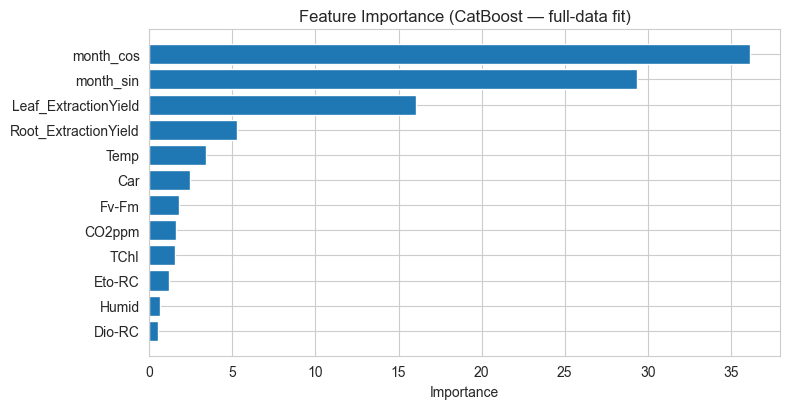

saved → artifacts/feature_importance_overall.png


In [5]:
# =========================================================
# Scenario-wise Metrics Table (+ Feature Importance plot)
#  - 시나리오별 LOGO(LOSO)로 MAE/RMSE/MAPE 산출
#  - 표는 열=시나리오, 행=지표(MAE/RMSE/MAPE)
#  - 하단에 전체 학습(풀데이터) 기준 피처 중요도 바차트
# =========================================================
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor, Pool

sns.set_style("whitegrid")

# ---------- 0) 환경 준비 & 안전 로드 ----------
META_P = "model/metadata.json"
DATA_P = "data/processed/processed.csv"

def ensure_loaded():
    glb = globals()
    if all(k in glb for k in ["final_model","X","y","groups"]):
        # 메모리 변수 사용
        feature_cols = list(glb["X"].columns) if isinstance(glb["X"], pd.DataFrame) else None
        targets = list(glb["y"].columns) if isinstance(glb["y"], pd.DataFrame) else None
        return glb["final_model"], glb["X"], (glb["y"].values if hasattr(glb["y"],"values") else glb["y"]), glb["groups"], feature_cols, targets

    # 디스크에서 복구
    if not os.path.exists(META_P) or not os.path.exists(DATA_P):
        raise FileNotFoundError("final_model/X/y/groups가 메모리에 없고, model/metadata.json 또는 data/processed/processed.csv가 없습니다.")
    with open(META_P, "r", encoding="utf-8") as f:
        meta = json.load(f)
    feature_cols = meta["feature_cols"]
    targets = meta.get("target_names", ["Leaf_TPC","Root_TPC","Leaf_TFC","Root_TFC"])

    df = pd.read_csv(DATA_P)
    if "scenario_group" not in df.columns and "CO2ppm" in df.columns:
        # 01_preprocessing과 같은 경계
        def scenario_label(co2):
            if co2 < 633:   return "SSP1-2.6"
            elif co2 < 961: return "SSP3-7.0"
            else:           return "SSP5-8.5"
        df["scenario_group"] = df["CO2ppm"].apply(scenario_label)

    # 모델 로드
    model = CatBoostRegressor()
    model.load_model("model/final_catboost_multi.cbm")

    X = df[feature_cols].copy()
    y = df[targets].copy().values
    groups = df["scenario_group"].astype(str).values
    return model, X, y, groups, feature_cols, targets

final_model, X, y, groups, feature_cols, targets = ensure_loaded()
Xv = X.values if isinstance(X, pd.DataFrame) else X
assert y.ndim == 2, "y는 (n_samples, n_targets) 2D여야 합니다."

# ---------- 1) 지표 함수 ----------
def mape(y_true, y_pred, eps=1e-8):
    yt = np.asarray(y_true); yp = np.asarray(y_pred)
    # 4개 타깃 각각의 MAPE → 평균
    per_tgt = []
    for i in range(yt.shape[1]):
        denom = np.clip(np.abs(yt[:,i]), eps, None)
        per_tgt.append(np.mean(np.abs((yt[:,i] - yp[:,i]) / denom)))
    return float(np.mean(per_tgt))

def mae_rmse(y_true, y_pred):
    maes  = [mean_absolute_error(y_true[:,i], y_pred[:,i]) for i in range(y_true.shape[1])]
    rmses = [np.sqrt(mean_squared_error(y_true[:,i], y_pred[:,i])) for i in range(y_true.shape[1])]
    return float(np.mean(maes)), float(np.mean(rmses))

# ---------- 2) 시나리오별 LOGO 평가 ----------
scenarios = np.unique(groups)
gkf = GroupKFold(n_splits=len(scenarios))

# 동일 파라미터로 각 폴드에서 재학습(권장, 공정)
def build_multi_from_meta(meta_path="model/metadata.json", seed=42):
    with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)
    p = meta["best_params"]
    return CatBoostRegressor(
        loss_function="MultiRMSE",
        iterations=p.get("iterations", 3000),
        learning_rate=p["learning_rate"],
        depth=p["depth"],
        l2_leaf_reg=p["l2_leaf_reg"],
        bootstrap_type="Bernoulli",
        subsample=p["subsample"],
        colsample_bylevel=p["colsample_bylevel"],
        random_strength=p["random_strength"],
        random_seed=seed,
        verbose=False
    )

rows=[]
for tr, te in gkf.split(Xv, y, groups):
    scen = np.unique(groups[te])[0]
    m = build_multi_from_meta()
    m.fit(Xv[tr], y[tr], eval_set=Pool(Xv[te], y[te]), early_stopping_rounds=200, verbose=False)
    pred = m.predict(Xv[te])
    _mae, _rmse = mae_rmse(y[te], pred)
    _mape = mape(y[te], pred)
    rows.append({"scenario": scen, "MAE": _mae, "RMSE": _rmse, "MAPE": _mape})

df_metrics = pd.DataFrame(rows).set_index("scenario").T  # 행=지표, 열=시나리오
df_metrics = df_metrics.loc(["MAE","RMSE","MAPE"]) if isinstance(df_metrics.index, pd.MultiIndex) else df_metrics  # 안전
df_metrics = df_metrics.loc[["MAE","RMSE","MAPE"]]  # 행 순서 고정

print("=== Scenario-wise LOGO Metrics (mean over 4 targets) ===")
display(df_metrics.round(3))

# CSV 저장
os.makedirs("artifacts", exist_ok=True)
df_metrics.round(6).to_csv("artifacts/metrics_scenariowise_logo.csv", encoding="utf-8")
print("saved → artifacts/metrics_scenariowise_logo.csv")

# ---------- 3) (옵션) 표를 대회 템플릿처럼 보기 좋게 스타일링 ----------
try:
    styled = (df_metrics.round(3)
              .style.set_caption("Scenario-wise Metrics (LOGO)")
              .set_table_styles([{'selector':'th','props':'text-align:center;'},
                                 {'selector':'caption','props':'caption-side:top;font-weight:bold;'}])
              .format("{:.3f}"))
    display(styled)
except Exception:
    pass

# ---------- 4) 피처 중요도 바차트 (풀데이터 학습 모델 기준) ----------
try:
    imp = final_model.get_feature_importance(Pool(Xv, y))
    s = pd.Series(imp, index=feature_cols).sort_values(ascending=True)
    plt.figure(figsize=(8, max(4, 0.35*len(s))))
    plt.barh(s.index, s.values)
    plt.title("Feature Importance (CatBoost — full-data fit)")
    plt.xlabel("Importance")
    plt.tight_layout()
    os.makedirs("artifacts", exist_ok=True)
    plt.savefig("artifacts/feature_importance_overall.png", dpi=160)
    plt.show()
    print("saved → artifacts/feature_importance_overall.png")
except Exception as e:
    print(f"[중요도 플롯 스킵] {e}")